## Practical 2: Data Wrangling II
### Academic Performance Dataset – Python Implementation

### Objective

#### To create an Academic Performance dataset and perform:
#####   1.Missing value & inconsistency handling
#####   2.Outlier detection & treatment
#####   3.Data transformation with proper justification

### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### 0. Creating dataset


In [2]:
# Creating dataset
data = {
    "Student_ID": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Math_Score": [78, 85, np.nan, 92, 55, 300, 88, 76, 90, 60],
    "Science_Score": [82, 89, 75, 95, np.nan, 91, 87, 73, 88, 65],
    "English_Score": [70, 88, 76, 90, 60, 85, np.nan, 72, 89, 58],
    "Attendance": [85, 90, 88, np.nan, 70, 95, 92, 89, 93, 40],
    "Study_Hours": [2, 3, 2.5, 4, 1, 10, 3.5, 2, 5, 0.5]
}

df = pd.DataFrame(data)
df


,Student_ID,Math_Score,Science_Score,English_Score,Attendance,Study_Hours
0,1,78.0,82.0,70.0,85.0,2.0
1,2,85.0,89.0,88.0,90.0,3.0
2,3,NaN,75.0,76.0,88.0,2.5
3,4,92.0,95.0,90.0,NaN,4.0
4,5,55.0,NaN,60.0,70.0,1.0
5,6,300.0,91.0,85.0,95.0,10.0
6,7,88.0,87.0,NaN,92.0,3.5
7,8,76.0,73.0,72.0,89.0,2.0
8,9,90.0,88.0,89.0,93.0,5.0
9,10,60.0,65.0,58.0,40.0,0.5


### 1. Missing Values & Inconsistencies

In [3]:
df.isnull().sum()


Student_ID       0
Math_Score       1
Science_Score    1
English_Score    1
Attendance       1
Study_Hours      0
dtype: int64

### Inconsistencies Found
### Handling Strategy
#### I. Missing numeric values → Replace with mean
#### II. Invalid score (300) → Replace with median

In [4]:
# Fixing inconsistency
df.loc[df["Math_Score"] > 100, "Math_Score"] = df["Math_Score"].median()

# Handling missing values using mean
df.fillna(df.mean(numeric_only=True), inplace=True)

df


,Student_ID,Math_Score,Science_Score,English_Score,Attendance,Study_Hours
0,1,78.000000,82.000000,70.000000,85.000000,2.0
1,2,85.000000,89.000000,88.000000,90.000000,3.0
2,3,78.777778,75.000000,76.000000,88.000000,2.5
3,4,92.000000,95.000000,90.000000,82.444444,4.0
4,5,55.000000,82.777778,60.000000,70.000000,1.0
5,6,85.000000,91.000000,85.000000,95.000000,10.0
6,7,88.000000,87.000000,76.444444,92.000000,3.5
7,8,76.000000,73.000000,72.000000,89.000000,2.0
8,9,90.000000,88.000000,89.000000,93.000000,5.0
9,10,60.000000,65.000000,58.000000,40.000000,0.5


### 2. Outlier Detection & Treatment
##### Using Boxplot

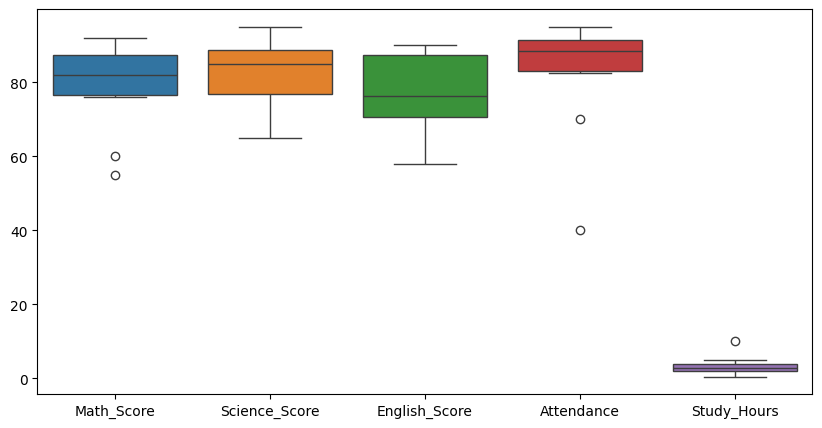

In [5]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df.drop(columns="Student_ID"))
plt.show()


### Outlier Handling Technique
##### Interquartile Range (IQR) Method

In [6]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df_outlier_fixed = df.copy()
df_outlier_fixed = df_outlier_fixed[~(
    (df_outlier_fixed < (Q1 - 1.5 * IQR)) |
    (df_outlier_fixed > (Q3 + 1.5 * IQR))
).any(axis=1)]

df_outlier_fixed


,Student_ID,Math_Score,Science_Score,English_Score,Attendance,Study_Hours
0,1,78.000000,82.0,70.000000,85.000000,2.0
1,2,85.000000,89.0,88.000000,90.000000,3.0
2,3,78.777778,75.0,76.000000,88.000000,2.5
3,4,92.000000,95.0,90.000000,82.444444,4.0
6,7,88.000000,87.0,76.444444,92.000000,3.5
7,8,76.000000,73.0,72.000000,89.000000,2.0
8,9,90.000000,88.0,89.000000,93.000000,5.0


### 3. Data Transformation


In [7]:
df_outlier_fixed["Log_Study_Hours"] = np.log1p(df_outlier_fixed["Study_Hours"])


### Before & After Visualization


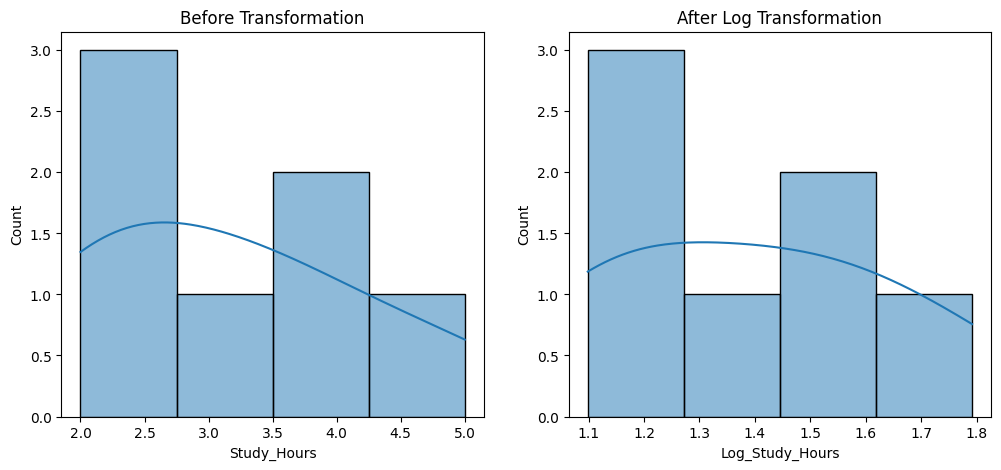

In [8]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df_outlier_fixed["Study_Hours"], kde=True)
plt.title("Before Transformation")

plt.subplot(1,2,2)
sns.histplot(df_outlier_fixed["Log_Study_Hours"], kde=True)
plt.title("After Log Transformation")

plt.show()


### Final Dataset


In [9]:
df_outlier_fixed


,Student_ID,Math_Score,Science_Score,English_Score,Attendance,Study_Hours,Log_Study_Hours
0,1,78.000000,82.0,70.000000,85.000000,2.0,1.098612
1,2,85.000000,89.0,88.000000,90.000000,3.0,1.386294
2,3,78.777778,75.0,76.000000,88.000000,2.5,1.252763
3,4,92.000000,95.0,90.000000,82.444444,4.0,1.609438
6,7,88.000000,87.0,76.444444,92.000000,3.5,1.504077
7,8,76.000000,73.0,72.000000,89.000000,2.0,1.098612
8,9,90.000000,88.0,89.000000,93.000000,5.0,1.791759
